**IMPORT REQUIRED LIBRARIES**

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [27]:
df = pd.read_csv("/content/ai4i2020.csv")
df

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,M24855,M,298.8,308.4,1604,29.5,14,0,0,0,0,0,0
9996,9997,H39410,H,298.9,308.4,1632,31.8,17,0,0,0,0,0,0
9997,9998,M24857,M,299.0,308.6,1645,33.4,22,0,0,0,0,0,0
9998,9999,H39412,H,299.0,308.7,1408,48.5,25,0,0,0,0,0,0


In [28]:
df.shape

(10000, 14)

**SIMPLE LINEAR REGRESSION**

In [29]:
x = df[['Rotational speed [rpm]']]
y = df[['Process temperature [K]']]

In [30]:
from sklearn.linear_model import LinearRegression
f = LinearRegression()
f.fit(x,y)
y_pred = f.predict(x)
y_pred

array([[310.0075101 ],
       [309.98469705],
       [309.99905491],
       ...,
       [310.02250609],
       [309.98469705],
       [309.99937398]])

In [31]:
f.coef_

array([[0.00015953]])

In [32]:
f.intercept_

array([309.76007623])

In [33]:
from sklearn.metrics import mean_squared_error
mse = mean_squared_error(y, y_pred)
print("Mean Squared Error:", mse)

Mean Squared Error: 2.2004291212555707


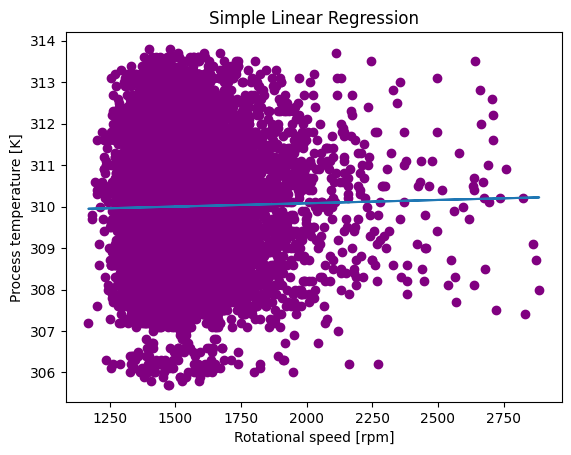

In [34]:
plt.scatter(x,y,color = "purple")
plt.plot(x,y_pred)
plt.xlabel("Rotational speed [rpm]")
plt.ylabel("Process temperature [K]")
plt.title("Simple Linear Regression")
plt.show()

**MULTIVARIABLE REGRESSION**

In [35]:
x = df[[
    'Air temperature [K]',
    'Rotational speed [rpm]',
    'Torque [Nm]',
    'Tool wear [min]'
]]
y = df['Process temperature [K]']

In [36]:
f = LinearRegression()
f.fit(x,y)
y_pred = f.predict(x)
y_pred

array([308.75873021, 308.82999487, 308.75276044, ..., 309.35153257,
       309.34711275, 309.35288723])

In [37]:
print("Slope:",f.coef_)

Slope: [ 6.49915258e-01 -8.20600778e-05 -1.58677594e-03  3.07535752e-05]


In [38]:
print("Intercept:",f.intercept_)

Intercept: 115.21418109824944


In [39]:
mse = mean_squared_error(y, y_pred)
print("Mean Squared Error:", mse)

Mean Squared Error: 0.5115862237963301


**SAVE & LOAD THE MODEL**

In [41]:
import pickle
pickle.dump(f,open("temperature_model.pkl","wb"))

In [42]:
import joblib
joblib.dump(f,"temperature_model.pkl")

['temperature_model.pkl']

In [60]:
loaded = joblib.load("temperature_model.pkl")
data = pd.DataFrame([[
    298.5,
    1500,
    40,
    20
]], columns=[
    'Air temperature [K]',
    'Rotational speed [rpm]',
    'Torque [Nm]',
    'Tool wear [min]'
])
pred = loaded.predict(data)
print("Predicted Temperature:",pred)
# IF WE USE ABOVE 1ST ONE(BEST PRACTICE) - NO WARNING MSG OTHERWISE WE'LL GET WARNING MSG
print("\n")
u_pred = loaded.predict([[298.5,1500,40,20]]) # DATAFRAME INDICATED BY [[]]
print("Predicted Temperature:",u_pred)

Predicted Temperature: [309.02793942]


Predicted Temperature: [309.02793942]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


**ONE-HOT ENCODING**

In [47]:
print(df['Type'].head())

0    M
1    L
2    L
3    L
4    L
Name: Type, dtype: object


In [49]:
encoded = pd.get_dummies(df['Type']).astype(int)
encoded.head()

,H,L,M
0,0,0,1
1,0,1,0
2,0,1,0
3,0,1,0
4,0,1,0


In [58]:
encoded = pd.get_dummies(df['Type'],drop_first=True).astype(int)
# TO AVOID DUMMY VARIABLE TRAP WHICH CAUSE "multicollinearity - duplicate/redundant information", FOR THAT DROP ONE COLUMN
# MATHEMATICALLY

# Type_H = 1 − Type_L − Type_M
print("Encoded Dataset:\n")
encoded.head()

Encoded Dataset:



,L,M
0,0,1
1,1,0
2,1,0
3,1,0
4,1,0


In [66]:
df = pd.concat([df,encoded],axis=1)
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF,L,M
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0,0,1
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0,1,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0,1,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0,1,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0,1,0


**PERFORMING TRAIN TEST SPLIT**

In [62]:
from sklearn.model_selection import train_test_split

In [68]:
x = df[[
    'Air temperature [K]',
    'Rotational speed [rpm]',
    'Torque [Nm]',
    'Tool wear [min]',
    'L',
    'M'
]]
y = df['Process temperature [K]']

In [69]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [71]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(8000, 6)
(2000, 6)
(8000,)
(2000,)


In [72]:
m = LinearRegression()
m.fit(x_train,y_train)

LinearRegression()

In [73]:
y_p = m.predict(x_test)
y_p

array([310.53013565, 312.33127307, 308.87645539, ..., 310.18867414,
       307.94862904, 310.62963212])

In [74]:
mse_yy = mean_squared_error(y_test,y_p)
print("Mean Squared Error:",mse_yy)

Mean Squared Error: 0.5305603733573004


**LOGISTIC REGRESSION**

In [75]:
from sklearn.linear_model import LogisticRegression

In [77]:
x = df[[
    'Air temperature [K]',
    'Process temperature [K]',
    'Rotational speed [rpm]',
    'Torque [Nm]',
    'Tool wear [min]',
    'L',
    'M'
]]
y = df['Machine failure']

In [78]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [80]:
ml = LogisticRegression(max_iter = 1000)
ml.fit(x_train,y_train)

LogisticRegression(max_iter=1000)

In [81]:
y_pred = ml.predict(x_test)
y_pred

array([0, 0, 0, ..., 0, 0, 0])

In [82]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test,y_pred)
print("Confusion Matrix:\n",cm)

Confusion Matrix:
 [[1930    9]
 [  43   18]]


In [83]:
from sklearn.metrics import accuracy_score
acc = accuracy_score(y_test,y_pred)
print("Accuracy Score:",acc)

Accuracy Score: 0.974


In [84]:
from sklearn.metrics import classification_report
cr = classification_report(y_test,y_pred)
print("Classification Report:\n",cr)

Classification Report:
               precision    recall  f1-score   support

           0       0.98      1.00      0.99      1939
           1       0.67      0.30      0.41        61

    accuracy                           0.97      2000
   macro avg       0.82      0.65      0.70      2000
weighted avg       0.97      0.97      0.97      2000

